# AG-HYPOPT · Trial 26

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-five trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803. Then trial_20 (sw 0.922, h_f 3.899, h_s 3.615, cap 0.203) 0.0821, trial_05 0.0822, trial_09 0.0839, trial_18 0.0844, trial_16 0.0850, trial_21 0.0852, trial_22 0.0853, trial_11 0.0859, trial_17 0.0859, trial_06 0.0861, trial_15 0.0865, trial_25 0.0865, ... up to trial_10 0.0922. All 0 diverged, gamma finite. trial_07 is an isolated sharp optimum; the sigma-weight optimum is interior (~0.87-0.92), the kernel flatness optimum is interior (h_s ~3.6-3.7, h_f ~3.9-4.0), and trials 08-25 have not beaten trial_07. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_26'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (25/5 trials)
ID |     ei | params
 1 | 2.8915 | {"gamma_rel_cap": 0.10704245412657526, "h_f_scale": 2.9232182645579265, "h_s_scale": 3.602960324306206, "sigma_weight": 0.9030161990160427}
 2 | 3.6029 | {"gamma_rel_cap": 0.24937143716725452, "h_f_scale": 3.9303395057258745, "h_s_scale": 3.6076431163446365, "sigma_weight": 0.859747652089494}
 3 | 2.7679 | {"gamma_rel_cap": 0.15924200249006185, "h_f_scale": 3.905037212853058, "h_s_scale": 3.6795102576397247, "sigma_weight": 0.5653390980882042}
 4 | 3.5962 | {"gamma_rel_cap": 0.24513239742493526, "h_f_scale": 3.9258169105633574, "h_s_scale": 3.617249673070748, "sigma_weight": 0.8277217100054522}
 5 | 3.3155 | {"gamma_rel_cap": 0.31313619873636156, "h_f_scale": 4.0, "h_s_scale": 3.6282137084861485, "sigma_weight": 0.9466559656045199}
 6 | 3.4653 | {"gamma_rel_cap": 0.07470200215299383, "h_f_scale": 3.2216883410526913, "h_s_scale": 3.6111034226986507, "sigma_weight": 0.43512743015187993}
 7 | 3.5407 | {"gamma_rel_cap": 0.037

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is an isolated sharp optimum; trial_20 (0.0821) is the best reproducible design. The batch is again near-copies. Candidate 8 is the highest-ei draw in the successful high-sw region.

Candidate 8 (ei 3.8086) has sw 0.919 (close to trial_20's 0.922), h_f 4.0, h_s 3.608 and a cap of 0.163. It sits in the trial_20 design but with the smaller cap that trial_21 already showed to be worse (0.157 -> 0.0852), so it tops the batch on the model's score while being an in-region probe with a mostly-known outcome; the other top draws move sw or the cap further off optimum.

I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # candidate 8: sigma_weight 0.919, h_f_scale 4.0, h_s_scale 3.608, gamma_rel_cap 0.163 (trial_20 region)


chosen: {'gamma_rel_cap': 0.16315733898046075, 'h_f_scale': 4.0, 'h_s_scale': 3.607756394671288, 'sigma_weight': 0.9186735056892578}
Running  1nW Trans05 ... 

μ 9.39 -> 5.93 | γ 8.5 -> 5.21 | NLL 0.26


Running  1nW Trans20 ... 

μ 17.32 -> 27.34 | γ 8.5 -> 5.38 | NLL 0.67


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 67.62 | γ 14.1 -> 14.01 | NLL 0.71


Running 3nW Trans100 ... 

μ 175.71 -> 99.89 | γ 14.1 -> 13.82 | NLL 0.67



Total: 7.8 min


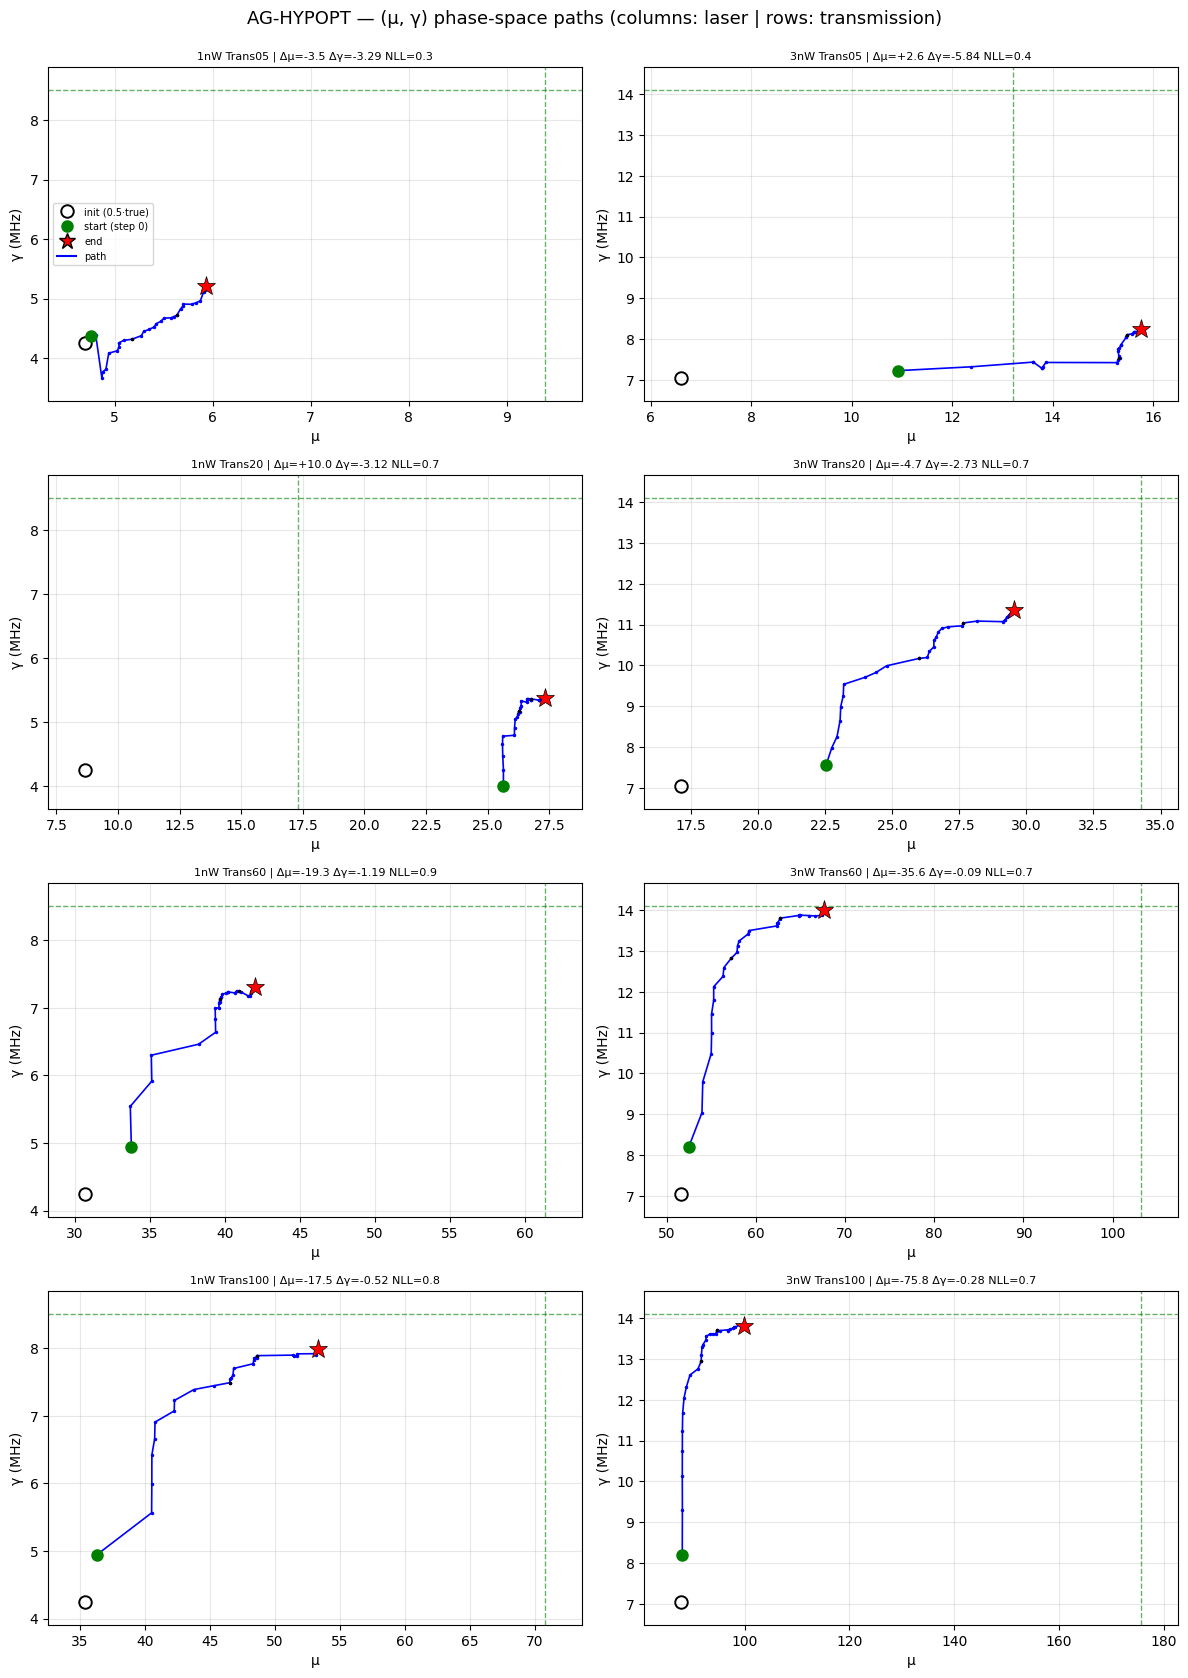

trial finished in 7.8 min
objective = 0.0807 ± 0.0228
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.93   -36.9 |     8.50    5.21   -38.8
1nW Trans20       17.32   27.34   +57.9 |     8.50    5.38   -36.7
1nW Trans60       61.37   42.05   -31.5 |     8.50    7.31   -14.0
1nW Trans100       70.82   53.35   -24.7 |     8.50    7.98    -6.1
3nW Trans05       13.20   15.77   +19.4 |    14.10    8.26   -41.5
3nW Trans20       34.28   29.55   -13.8 |    14.10   11.37   -19.4
3nW Trans60      103.20   67.62   -34.5 |    14.10   14.01    -0.6
3nW Trans100      175.71   99.89   -43.1 |    14.10   13.82    -2.0

weighted objective (T-graded, cap=1.0) = 0.0807 | diverged cells: 0
μ: RMSE 31.293 (rel 35.2%, bias -17.974) | γ: RMSE 2.827 (rel 25.4%, bias -2.133)


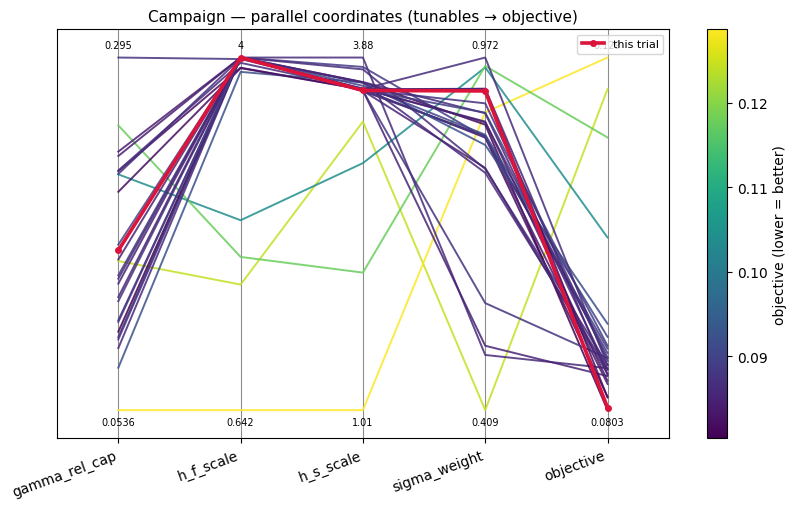

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 26 (sw 0.919, h_f 4.0, h_s 3.608, cap 0.163) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0807 +/- 0.0228 - the second-best trial, essentially tied with trial_07 (0.0803) and clearly ahead of the rest of the cluster.

mu rel-RMSE 35.2% (better than trial_07's 35.9% and second only to trial_06's 34.0%): same shape - high-T undershoot (3nW Trans100 -43.1%, 3nW Trans60 -34.5%, 1nW Trans60 -31.5%, 1nW Trans100 -24.7%), low-T overshoot (1nW Trans20 +57.9%, 3nW Trans05 +19.4%); bias -17.97.

gamma rel-RMSE 25.4% (worse than trial_07's 22.3%): low T under-estimated (3nW Trans05 -41.5%, 1nW Trans05 -38.8%, 1nW Trans20 -36.7%), high T near truth (-0.6%, -2.0%).

The candidate lay in the high-sigma-weight region (sw 0.919, near trial_20's 0.922) with a mid cap (0.163) and matched trial_07 almost exactly. This shows the optimum is not unique: a second near-optimal configuration exists in the high-sw corner (sw ~0.92, flat kernels, cap ~0.16-0.20), and the objective there is on par with trial_07's.

**Summary:** Trial 26 (sw=0.919, h_f=4.0, h_s=3.608, cap=0.163) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0807 +/- 0.0228 - second best, essentially tied with trial_07 (mu rel-RMSE 35.2%, gamma rel-RMSE 25.4%).
**Key insight:** A high-sigma-weight design (sw 0.919) with a mid cap (0.163) reached 0.0807, matching trial_07 within noise, so the optimum is not unique: a second near-optimal point exists in the high-sw corner.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 26 (sw=0.919, h_f=4.0, h_s=3.608, cap=0.163): objective 0.0807 +/- 0.0228 - second best, essentially tied with trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 35.2%, gamma rel-RMSE 25.4%).'
KEY_INSIGHT = 'A high-sigma-weight design (sw 0.919) with a mid cap (0.163) reached 0.0807, matching trial_07 within noise, so the optimum is not unique: a second near-optimal point exists in the high-sw corner.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_26 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_27.ipynb. Open it and follow its cells from the top.
